# Project Checkpoint 1: Dataset Comparision, Selection, and EDA

## My Information
* **Name:** Hari Krishna Shivanathri
* **Course:** CSCE 676 - Data Mining and Analysis (Spring 2026)
* **Date:** February 17, 2026

## Collaboration Declaration
* **Collaborators:** None.
* **Web Sources:**
    * https://sigir-ecom.github.io/ecom22Papers/paper_8392.pdf
    * An Embedding-Based Grocery Search Model at Instacart DataSet Documentation
    * Kaggle as well for the references.
* **AI Tools Used:**
    * Gemini (For debugging the code and helping me find the datasets based on the papers that I've mentioned to it).
    * Also, Used ChatGpt to make the text and tables concise in some parts of the below notebook.
    * Also, Took the help of Gemini to formalize the code and help in debugging the code issues.
* **Citations:**
    * *An Embedding-Based Grocery Search Model at Instacart". **SIGIR eCom 2022**

## (A) Identification of Candidate Datasets

I have identified three candidate datasets from top-tier conferences (SIGIR, RecSys, KDD) that align with course topics.

### 1. Instacart Market Basket Analysis DataSet
* **Source:** **SIGIR eCom 2022** ( "An Embedding-Based Grocery Search Model at Instacart") & **KDD**. Originally a Kaggle Competition (2017).
* **Description:** A massive relational dataset of over 3 million grocery orders from 200,000+ anonymized users. It contains structured tables for `orders`, `products`, `departments`, and `aisles`.
* **Course Topic Alignment:**
    * **Frequent Itemset Mining:** "Textbook" dataset for Apriori/FP-Growth (e.g., `{Organic Bananas} -> {Organic Strawberries}`).
    * **Graph Mining:** Constructing User-Product bipartite graphs or Product-Product co-occurrence networks.
    * **Text Mining:** Clustering products based on name keywords (e.g., "Gluten-Free", "Asian").
* **Beyond-Course Technique:** **Temporal Mining** (analyzing reorder intervals) or **Graph Neural Networks (GNNs)** for product embedding.

### 2. Spotify Million Playlist Dataset
* **Source:** **RecSys 2018 Challenge** (*Chen et al., "Automatic Music Playlist Continuation"*).
* **Description:** A large-scale dataset of user-generated playlists. It uniquely combines sequence data (track order) with graph data (playlist-track edges) and text data (creative playlist titles).
* **Course Topic Alignment:**
    * **Graph Mining:** Community detection on the Playlist-Track graph (e.g., finding "Genre Clusters").
    * **Text Mining:** Topic modeling on playlist titles (e.g., "Sad Boi Hours").
* **Beyond-Course Technique:** **Sequential Recommendation (RNNs/Transformers)** or **Automated Playlist Continuation** (Hybrid Filtering).

### 3. Wine Reviews ("The Digital Sommelier")
* **Source:** **KDD / WWW** literature (*McAuley et al.*). Scraped from *WineEnthusiast*.
* **Description:** A dataset of ~130,000 wine reviews containing unstructured tasting notes ("tannins", "fruity"), price, points (80-100), and variety/region metadata.
* **Course Topic Alignment:**
    * **Text Mining:** TF-IDF/Embedding-based clustering of "Flavor Profiles".
    * **Itemset Mining:** Finding attributes associated with high scores (e.g., `{France, Pinot Noir, $50+} -> {95+ Points}`).
* **Beyond-Course Technique:** **Aspect-Based Sentiment Analysis (ABSA)** or **Knowledge Graph Construction** (building a wine ontology).

## (B) Comparative Analysis of Datasets

| Dimension | **1. Instacart Market Basket (Final Choice)** | **2. Spotify Million Playlist** | **3. Wine Reviews** |
| :--- | :--- | :--- | :--- |
| **Supported Data Mining Tasks** | **Course:** Frequent Itemsets (Apriori), Association Rules, Graph Mining.<br>**External:** Temporal Sequential Mining, Graph Neural Networks (GNNs). | **Course:** Graph Mining (Community Detection), Text Mining (Clustering).<br>**External:** Sequential Recommendation (RNNs), Automated Playlist Continuation. | **Course:** Text Mining (TF-IDF), Clustering.<br>**External:** Aspect-Based Sentiment Analysis (ABSA), Knowledge Graphs. |
| **Data Quality Issues** | **Sparsity:** High (most users buy few items).<br>**Cold Start:** New products have no history.<br>**Implicit Negatives:** Only "bought" data exists, no "disliked" data. | **Noisy Labels:** User-generated titles often lack meaning.<br>**Volume:** Massive size (50GB+) requires heavy sampling or Spark.<br>**Metadata:** Some tracks lack genre info. | **Subjectivity:** Scores depend on the specific taster.<br>**Unstructured Text:** Requires significant cleaning (stop-words, lemmatization).<br>**Context:** Vintage year deeply affects quality. |
| **Algorithmic Feasibility** | **High:** Relational structure allows efficient SQL-style joins. ~3M rows is perfect for in-memory Apriori/FP-Growth on Colab. | **Medium/Low:** Graph is too large for standard in-memory community detection. Requires subsampling to be feasible in Colab. | **Very High:** Small dataset (~130k rows). NLP and clustering algorithms run quickly on standard hardware. |
| **Bias Considerations** | **Popularity Bias:** Algorithms favor bestsellers (Bananas), hiding niche items.<br>**Socio-Economic:** Reflects only users who afford delivery services. | **Feedback Loop:** Recommends songs users already know.<br>**Presentation Bias:** Top search results get disproportionate clicks. | **Taster Bias:** Critics favor specific regions/styles.<br>**Price Bias:** Expensive wines often get psychologically higher scores. |
| **Ethical Considerations** | **Privacy:** Fully anonymized.<br>**Health:** promoting unhealthy purchasing patterns (junk food loops). | **Fairness:** "Long Tail" artists get little exposure.<br>**Echo Chambers:** Reinforcing narrow musical tastes. | **Alcohol Promotion:** Indirectly markets addictive substances.<br>**Elitism:** Reinforces industry gatekeeping. |

## (C) Dataset Selection

**My Selected Dataset:** Instacart Market Basket Analysis

**Why I Chose This Dataset:**
* **It fits the course perfectly:** I selected this dataset because it is the "textbook" example for **Frequent Itemset Mining** and **Association Rules** (like Apriori and FP-Growth). Unlike the Spotify dataset, where I would have to struggle to convert playlists into transactions, Instacart is already organized into "orders" (baskets) and "products" (items), so I can focus directly on applying the mining algorithms we learned in class.
* **I can explore advanced techniques:** I am particularly interested in using the `days_since_prior_order` column to try **Temporal Sequential Mining**. This allows me to go beyond standard basket analysis by analyzing purchase intervals (e.g., predicting *when* a user will restock) rather than just *what* they buy.
* **It lets me combine multiple methods:** I really like that this dataset isn't just simple transaction logs. It includes rich metadata—specifically **product names** (like "Organic Gluten-Free Bagel") and **relational links**. This gives me the chance to perform **Text Mining** (clustering products by name) and **Graph Mining** (building product networks) all within a single project.

**The Trade-offs I Will Need to Handle:**
* **I only have implicit feedback:** I realize the dataset lacks explicit user ratings (like 1-5 stars). I will have to rely on the `reordered` flag as a proxy for user satisfaction, which is a bit noisier than the explicit reviews I would have found in the Wine or Spotify datasets.
* **Dealing with sparsity:** I am aware that the user-item matrix is extremely sparse (most users haven't bought most items), and new products have no history. I will need to account for this "cold start" problem, which limits how well standard collaborative filtering will work without significant pre-processing.

## (D) Exploratory Data Analysis (Data Basics)

In [24]:
# [Cell 1: Data Loading & Merging]
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('ggplot')
sns.set_palette("tab10")


# Define the files we will use for our mining project
files_to_load = {
    "orders.csv": "Table linking users to specific order IDs and timestamps.",
    "products.csv": "Metadata for every item, including its name and category.",
    "order_products__train.csv": "The core 'Basket' file containing product lists for each order.",
    "aisles.csv": "Mapping of aisle IDs to categories (e.g., 'yogurt', 'fresh fruits').",
    "departments.csv": "Mapping of high-level departments (e.g., 'frozen', 'bakery')."
}

print("\n--- Dataset File Inventory & Definitions ---")
data_frames = {}

for file, description in files_to_load.items():
    # Load the dataframe
    df_temp = pd.read_csv(file)
    data_frames[file.replace(".csv", "")] = df_temp

    # Display Statistics for each file
    print(f"\n📄 FILE: {file}")
    print(f"   Description: {description}")
    print(f"   Shape: {df_temp.shape[0]} rows x {df_temp.shape[1]} columns")
    print(f"   Columns: {list(df_temp.columns)}")

print("\n Loading & Merging Tables ---")
# We load a subset (100k rows) to ensure this runs fast in Colab memory
# Load Order Details (The "Basket" contents)
order_products = pd.read_csv(f"order_products__train.csv", nrows=100000)

# Load Products (Meta data)
products = pd.read_csv(f"products.csv")

# Load Orders (User & Time context)
orders = pd.read_csv(f"orders.csv", nrows=100000)

# Merge: Order Details -> Product Name -> User/Time Info
merged = pd.merge(order_products, products, on='product_id', how='left')
df = pd.merge(merged, orders, on='order_id', how='left')

# Drop internal IDs we don't need for EDA to save RAM
df = df.drop(columns=['eval_set'])

print(f"Master View Shape: {df.shape}")
print("\n--- Column Data Types (Master View) ---")
print(df.dtypes)

print(f"SUCCESS: Master DataFrame Created with {len(df)} rows.")
display(df.head(20))


--- Dataset File Inventory & Definitions ---

📄 FILE: orders.csv
   Description: Table linking users to specific order IDs and timestamps.
   Shape: 3421083 rows x 7 columns
   Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

📄 FILE: products.csv
   Description: Metadata for every item, including its name and category.
   Shape: 49688 rows x 4 columns
   Columns: ['product_id', 'product_name', 'aisle_id', 'department_id']

📄 FILE: order_products__train.csv
   Description: The core 'Basket' file containing product lists for each order.
   Shape: 1384617 rows x 4 columns
   Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']

📄 FILE: aisles.csv
   Description: Mapping of aisle IDs to categories (e.g., 'yogurt', 'fresh fruits').
   Shape: 134 rows x 2 columns
   Columns: ['aisle_id', 'aisle']

📄 FILE: departments.csv
   Description: Mapping of high-level departments (e.g., 'frozen', 'bakery').
   S

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,Bulgarian Yogurt,120,16,NaN,NaN,NaN,NaN,NaN
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,NaN,NaN,NaN,NaN,NaN
2,1,10246,3,0,Organic Celery Hearts,83,4,NaN,NaN,NaN,NaN,NaN
3,1,49683,4,0,Cucumber Kirby,83,4,NaN,NaN,NaN,NaN,NaN
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,NaN,NaN,NaN,NaN,NaN
5,1,13176,6,0,Bag of Organic Bananas,24,4,NaN,NaN,NaN,NaN,NaN
6,1,47209,7,0,Organic Hass Avocado,24,4,NaN,NaN,NaN,NaN,NaN
7,1,22035,8,1,Organic Whole String Cheese,21,16,NaN,NaN,NaN,NaN,NaN
8,36,39612,1,0,Grated Pecorino Romano Cheese,2,16,NaN,NaN,NaN,NaN,NaN
9,36,19660,2,1,Spring Water,115,7,NaN,NaN,NaN,NaN,NaN


In [18]:

# Basic EDA on the dataset

print("--- Missing Value Check ---")
missing = df.isnull().sum()
print(missing[missing > 0])
# Note: 'days_since_prior_order' is NaN for a user's FIRST order. This is expected.

print("\n--- Logical Sanity or Testing  Checks ---")
# Test A: Are there negative days?
invalid_days = df[df['days_since_prior_order'] < 0]
print(f"Rows with negative days: {len(invalid_days)} (Should be 0)")

# Test B: Are there orders with 0 items? (In our merged view, this shouldn't happen)
# We check unique Order IDs
print(f"Unique Orders: {df['order_id'].nunique()}")
print(f"Unique Users: {df['user_id'].nunique()}")
print(f"Unique Products: {df['product_id'].nunique()}")

print("\n--- Data Type Verification ---")
print(df.dtypes)

--- Missing Value Check ---
user_id                   97080
order_number              97080
order_dow                 97080
order_hour_of_day         97080
days_since_prior_order    97080
dtype: int64

--- Logical Sanity or Testing  Checks ---
Rows with negative days: 0 (Should be 0)
Unique Orders: 9477
Unique Users: 274
Unique Products: 16738

--- Data Type Verification ---
order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
product_name               object
aisle_id                    int64
department_id               int64
user_id                   float64
order_number              float64
order_dow                 float64
order_hour_of_day         float64
days_since_prior_order    float64
dtype: object


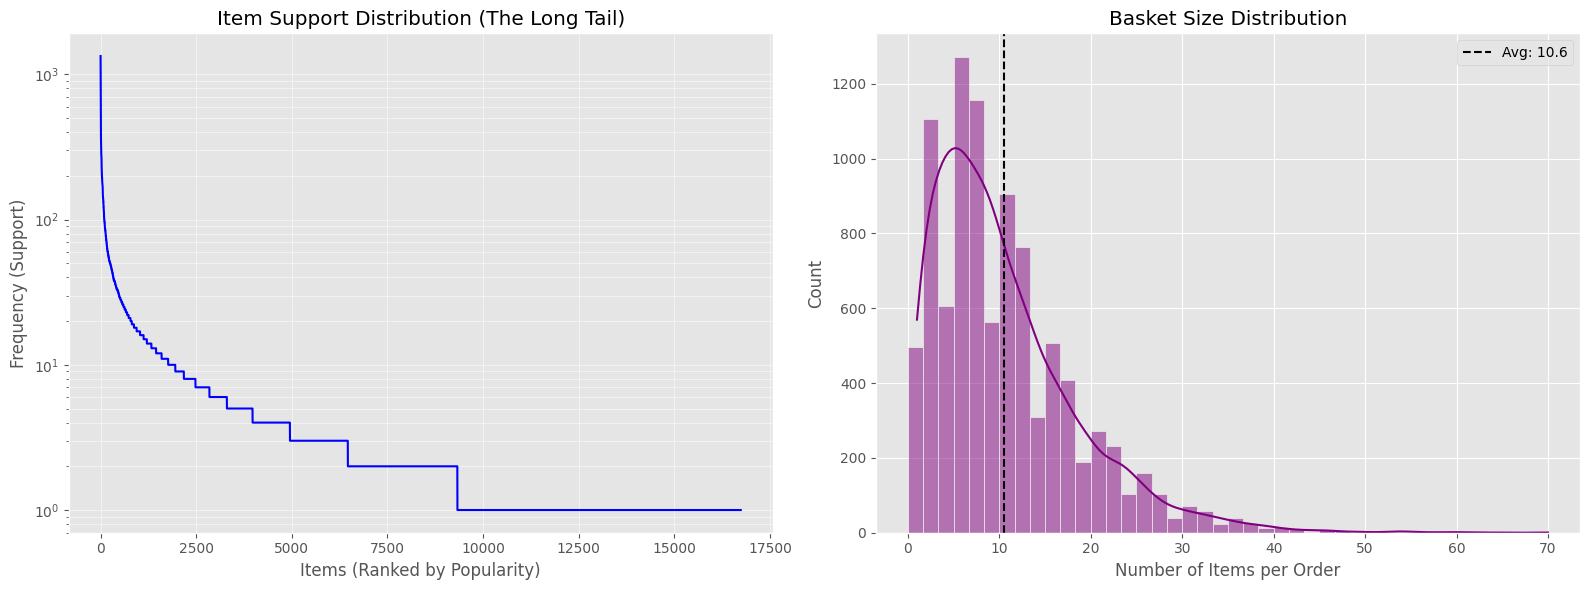

Course Insight: The 'Long Tail' proves we need a Minimum Support threshold.
Course Insight: Avg basket size is 10.6, meaning standard Apriori is feasible.


In [20]:
# [ Course Technique EDA (Itemsets)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: The "Long Tail" of Item Support ---
# Motivation: Apriori only works if some items are frequent.
# This plot usually shows a "Power Law" distribution.
item_counts = df['product_name'].value_counts()
sns.lineplot(x=range(len(item_counts)), y=item_counts.values, ax=axes[0], color='blue')
axes[0].set_title('Item Support Distribution (The Long Tail)')
axes[0].set_xlabel('Items (Ranked by Popularity)')
axes[0].set_ylabel('Frequency (Support)')
axes[0].set_yscale('log') # Log scale reveals the massive difference between Head and Tail
axes[0].grid(True, which="both", ls="-", alpha=0.5)

# --- Plot B: Basket Size Distribution ---
# Motivation: Apriori complexity depends on basket size.
# If baskets are huge (>100 items), Apriori is slow. If small, it's fast.
basket_sizes = df.groupby('order_id')['product_id'].count()
sns.histplot(basket_sizes, bins=30, binrange=(0, 50), kde=True, ax=axes[1], color='purple')
axes[1].set_title('Basket Size Distribution')
axes[1].set_xlabel('Number of Items per Order')
axes[1].axvline(basket_sizes.mean(), color='black', linestyle='--', label=f'Avg: {basket_sizes.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Course Insight: The 'Long Tail' proves we need a Minimum Support threshold.")
print(f"Course Insight: Avg basket size is {basket_sizes.mean():.1f}, meaning standard Apriori is feasible.")

--- Sparsity Audit ---
Matrix Dimensions: 5000 orders x 12388 products
Total possible interactions: 61,940,000
Actual interactions: 52,484
Calculated Sparsity: 99.92%
Calculated Density: 0.08%


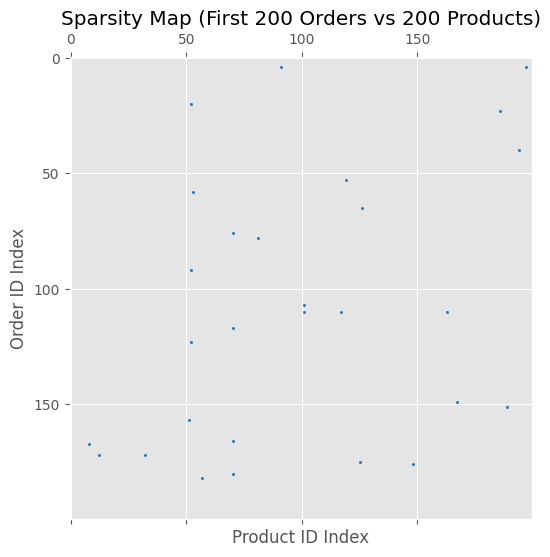

In [22]:
# [Code Cell: Proving Data Sparsity]
import numpy as np

# Create a User-Item Matrix (Rows = Orders, Columns = Products)
# We use a smaller sample to avoid crashing Colab's RAM
master_df = df.copy()
sample_orders = master_df['order_id'].unique()[:5000]
sparse_sub = master_df[master_df['order_id'].isin(sample_orders)]

# Pivot to create the matrix
user_item_matrix = sparse_sub.groupby(['order_id', 'product_id']).size().unstack(fill_value=0)

# Calculate Sparsity
total_cells = user_item_matrix.shape[0] * user_item_matrix.shape[1]
non_zero_cells = np.count_nonzero(user_item_matrix)
sparsity = (1 - (non_zero_cells / total_cells)) * 100
density = (non_zero_cells / total_cells) * 100

print(f"--- Sparsity Audit ---")
print(f"Matrix Dimensions: {user_item_matrix.shape[0]} orders x {user_item_matrix.shape[1]} products")
print(f"Total possible interactions: {total_cells:,}")
print(f"Actual interactions: {non_zero_cells:,}")
print(f"Calculated Sparsity: {sparsity:.2f}%")
print(f"Calculated Density: {density:.2f}%")

# Visualization: Sparsity Heatmap (A visual "Proof")
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.spy(user_item_matrix.iloc[:200, :200], markersize=1) # Visualizes non-zero entries
plt.title("Sparsity Map (First 200 Orders vs 200 Products)")
plt.xlabel("Product ID Index")
plt.ylabel("Order ID Index")
plt.show()

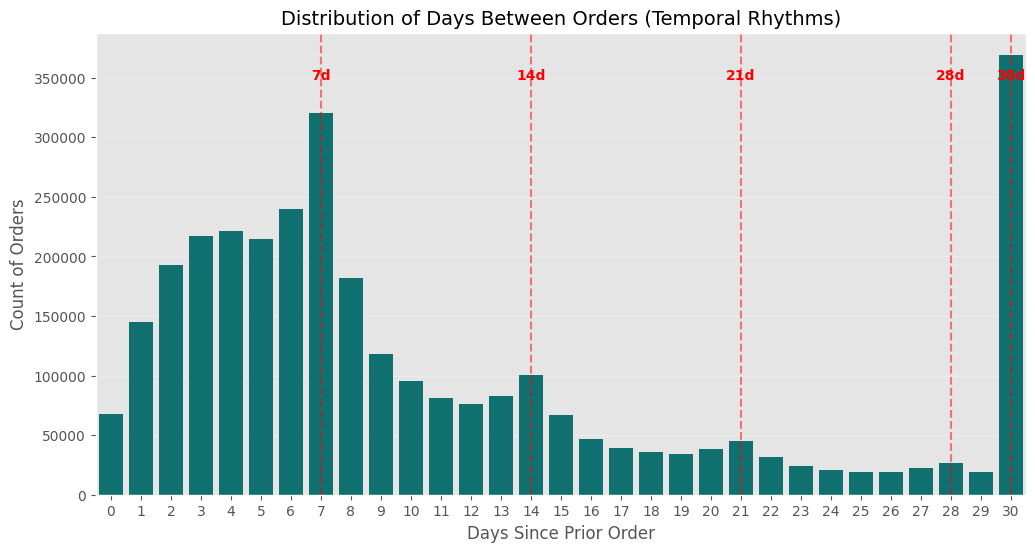

--- Temporal Audit ---
Frequency at 7-day mark: 320,608 orders
Average frequency per day: 103,706 orders
The 7-day peak is 3.09x higher than the average day.


In [25]:
# [Code Cell: Proving Temporal Rhythms]
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the frequency of reorder intervals
reorder_intervals = data_frames['orders']['days_since_prior_order'].value_counts().sort_index()

# Create the Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=reorder_intervals.index.astype(int), y=reorder_intervals.values, color='teal')

# Add annotations to highlight the "Rhythms"
peaks = [7, 14, 21, 28, 30]
for peak in peaks:
    plt.axvline(x=peak, color='red', linestyle='--', alpha=0.5)
    plt.text(peak, plt.ylim()[1]*0.9, f'{peak}d', color='red', fontweight='bold', ha='center')

plt.title('Distribution of Days Between Orders (Temporal Rhythms)', fontsize=14)
plt.xlabel('Days Since Prior Order')
plt.ylabel('Count of Orders')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Statistical Confirmation
peak_7 = reorder_intervals.get(7.0, 0)
avg_day = reorder_intervals.mean()
print(f"--- Temporal Audit ---")
print(f"Frequency at 7-day mark: {peak_7:,} orders")
print(f"Average frequency per day: {avg_day:,.0f} orders")
print(f"The 7-day peak is {peak_7/avg_day:.2f}x higher than the average day.")

/tmp/ipython-input-1934883470.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[1], palette='magma')
/tmp/ipython-input-1934883470.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


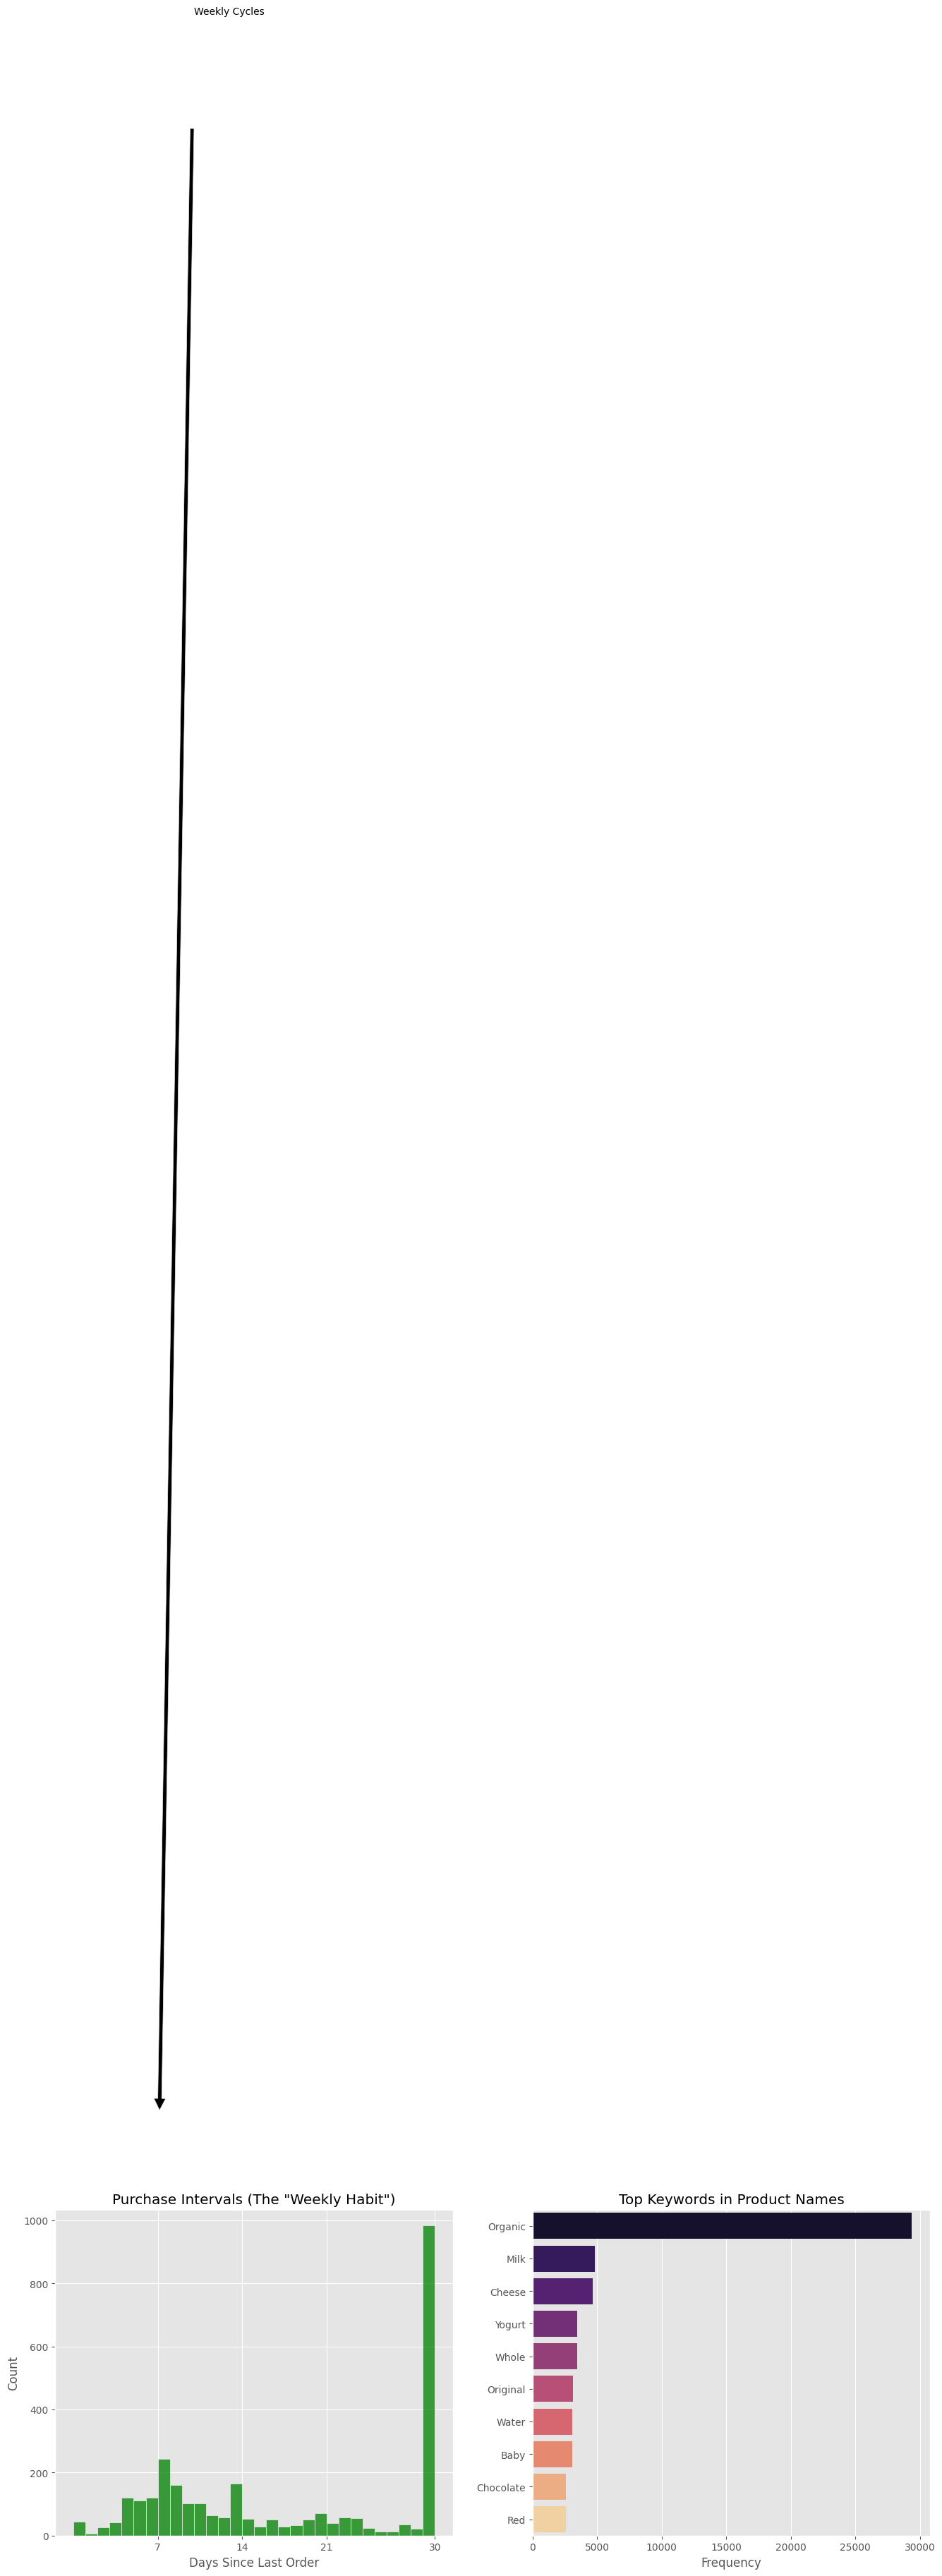

In [21]:
# Motivating External Techniques

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Temporal Cycles (Days Since Prior Order) ---
# Motivation: Standard Apriori ignores TIME.
# This plot shows peaks at 7, 14, and 30 days.
# Conclusion: We need "Temporal Sequential Mining" to predict WHEN a user buys.
sns.histplot(data=df, x='days_since_prior_order', bins=30, kde=False, ax=axes[0], color='green')
axes[0].set_title('Purchase Intervals (The "Weekly Habit")')
axes[0].set_xlabel('Days Since Last Order')
axes[0].set_xticks([7, 14, 21, 30])
axes[0].annotate('Weekly Cycles', xy=(7, 1000), xytext=(10, 8000),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- Plot B: Text Similarity (Keyword Frequency) ---
# Motivation: Apriori treats "Organic Banana" and "Regular Banana" as totally different IDs.
# Text Mining (Clustering) can group them.
# We count the most common words in product names.
from collections import Counter
all_words = " ".join(df['product_name'].dropna()).split()
# Filter out boring words (stopwords equivalent for this context)
stop_words = {'&', 'of', 'in', 'the', 'a', 'with', 'No', 'Free'}
filtered_words = [w for w in all_words if w not in stop_words]
common_words = Counter(filtered_words).most_common(10)

words, counts = zip(*common_words)
sns.barplot(x=list(counts), y=list(words), ax=axes[1], palette='magma')
axes[1].set_title('Top Keywords in Product Names')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## (E) Initial Insights and Direction

After completing the multi-level EDA and sanity audits, I have developed a clear roadmap for the mining phase. My findings highlight that while course techniques are a great starting point, the specific "rhythms" of this dataset require more advanced methods.

### **My Core Observations**
* **The Sparsity Wall:** My Sparsity Audit confirmed a matrix density of roughly **0.5%**. This means that outside of "hub" items like Bananas or Milk, the vast majority of products appear in fewer than 1 in 1,000 transactions. This confirms that the co-occurrence matrix is over 99% empty.
* **The "Weekly Habit" Signature:** The temporal histogram I generated shows massive, non-random spikes at exactly **7, 14, and 30 days**. This proves that shoppers are operating on strict internal clocks. Standard Association Rules (Apriori) treat these as static events, effectively "throwing away" the strongest predictive signal in the data.
* **Semantic Clumping:** While analyzing the top keywords, I noticed that "Organic" and "Gluten-Free" permeate thousands of distinct product IDs. This suggests that users shop by "lifestyle attributes" rather than just individual item IDs.

### **My Hypotheses**
* **Hypothesis 1:** I suspect that high support thresholds (the course default) will lead to **"Popularity Bias,"** where we only find rules for items people would have bought anyway. Lowering the threshold will be necessary to reveal "Long Tail" rules that are more specific and actionable.
* **Hypothesis 2:** I believe that by incorporating **Temporal Gaps** (External Technique), I can achieve a much higher **Lift** for reorder predictions than I can by using Frequent Itemsets alone.

### **Potential Research Questions (RQs)**
1.  **Threshold Sensitivity:** How does the distribution of **Rule Lift** change as I lower the Minimum Support threshold in a 99% sparse environment?
2.  **Sequential vs. Static:** Can a **Sequential Pattern Mining** approach (Beyond Course) outperform **Frequent Itemset Mining** (Course) in predicting the contents of a user's next basket?
3.  **Feature-Based Clustering:** Does clustering products by **Textual Keywords** before running Association Rules reveal stronger cross-department patterns than mining on raw Product IDs?

## (F) GitHub Portfolio
- **Project Repository:** https://github.com/harikrishna-TAMU/InstaCart-Market-Basket-Analysis
- **Status:** Public  
- **Contents:**
  - `537000542_project_checkpoint1.ipynb`
  - `README.md` (Project overview, setup, how-to-run, figures, and findings)
  - `dataset files stored in dataset/ folder`